In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1 ')

In [3]:
print("Shape :",df.shape)
print("\nColumns :",df.columns.tolist())
print("\nFirst 5 rows :\n",df.head())

Shape : (9994, 21)

Columns : ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 rows :
    Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...

In [4]:
print("=== Data Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Data Info ===
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Q

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
# convert date columns from string to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract useful columns from dates
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%B')
df['Order Quarter'] = df['Order Date'].dt.quarter

# Calculate how many days it took to ship each order
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Confirm changes
print("Date columns fixed : ")
print(df[['Order Date', 'Ship Date', 'Order Year', 'Order Month', 'Order Month Name', 'Order Quarter', 'Shipping Days']].head())
print("\nUpdated data types :")
print(df[['Order Date', 'Ship Date']].dtypes)

Date columns fixed : 
  Order Date  Ship Date  Order Year  Order Month Order Month Name  \
0 2016-11-08 2016-11-11        2016           11         November   
1 2016-11-08 2016-11-11        2016           11         November   
2 2016-06-12 2016-06-16        2016            6             June   
3 2015-10-11 2015-10-18        2015           10          October   
4 2015-10-11 2015-10-18        2015           10          October   

   Order Quarter  Shipping Days  
0              4              3  
1              4              3  
2              2              4  
3              4              7  
4              4              7  

Updated data types :
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [6]:
# Total Sales , Profit and Orders
print("=== Business Overview ===")
print(f"Total Revenue: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Total Orders: {df['Order ID'].nunique():,}")
print(f"Total Customers: {df['Customer ID'].nunique():,}")
print(f"Profit Margin: {df['Profit'].sum() / df['Sales'].sum() * 100:.2f}%")

print("\n=== Sales by Category ===")
print(df.groupby('Category')[['Sales', 'Profit']].sum().round(2))

print("\n=== Sales by Region ===")
print(df.groupby('Region')[['Sales', 'Profit']].sum().round(2))

print("\n=== Top 5 Sub-Categories by Sales ===")
print(df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(5).round(2))


=== Business Overview ===
Total Revenue: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Customers: 793
Profit Margin: 12.47%

=== Sales by Category ===
                     Sales     Profit
Category                             
Furniture        741999.80   18451.27
Office Supplies  719047.03  122490.80
Technology       836154.03  145454.95

=== Sales by Region ===
             Sales     Profit
Region                       
Central  501239.89   39706.36
East     678781.24   91522.78
South    391721.90   46749.43
West     725457.82  108418.45

=== Top 5 Sub-Categories by Sales ===
Sub-Category
Phones     330007.05
Chairs     328449.10
Storage    223843.61
Tables     206965.53
Binders    203412.73
Name: Sales, dtype: float64


In [7]:
# Which sub-categories are LOSING money?
print("=== Loss Making Sub-Categories ===")
loss = df.groupby('Sub-Category')['Profit'].sum().sort_values()
print(loss[loss < 0])

# which states are LOSING money?
print("\n=== Top 5 Loss Making States ===")
state_loss = df.groupby('State')['Profit'].sum().sort_values().head()
print(state_loss)

=== Loss Making Sub-Categories ===
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64

=== Top 5 Loss Making States ===
State
Texas            -25729.3563
Ohio             -16971.3766
Pennsylvania     -15559.9603
Illinois         -12607.8870
North Carolina    -7490.9122
Name: Profit, dtype: float64


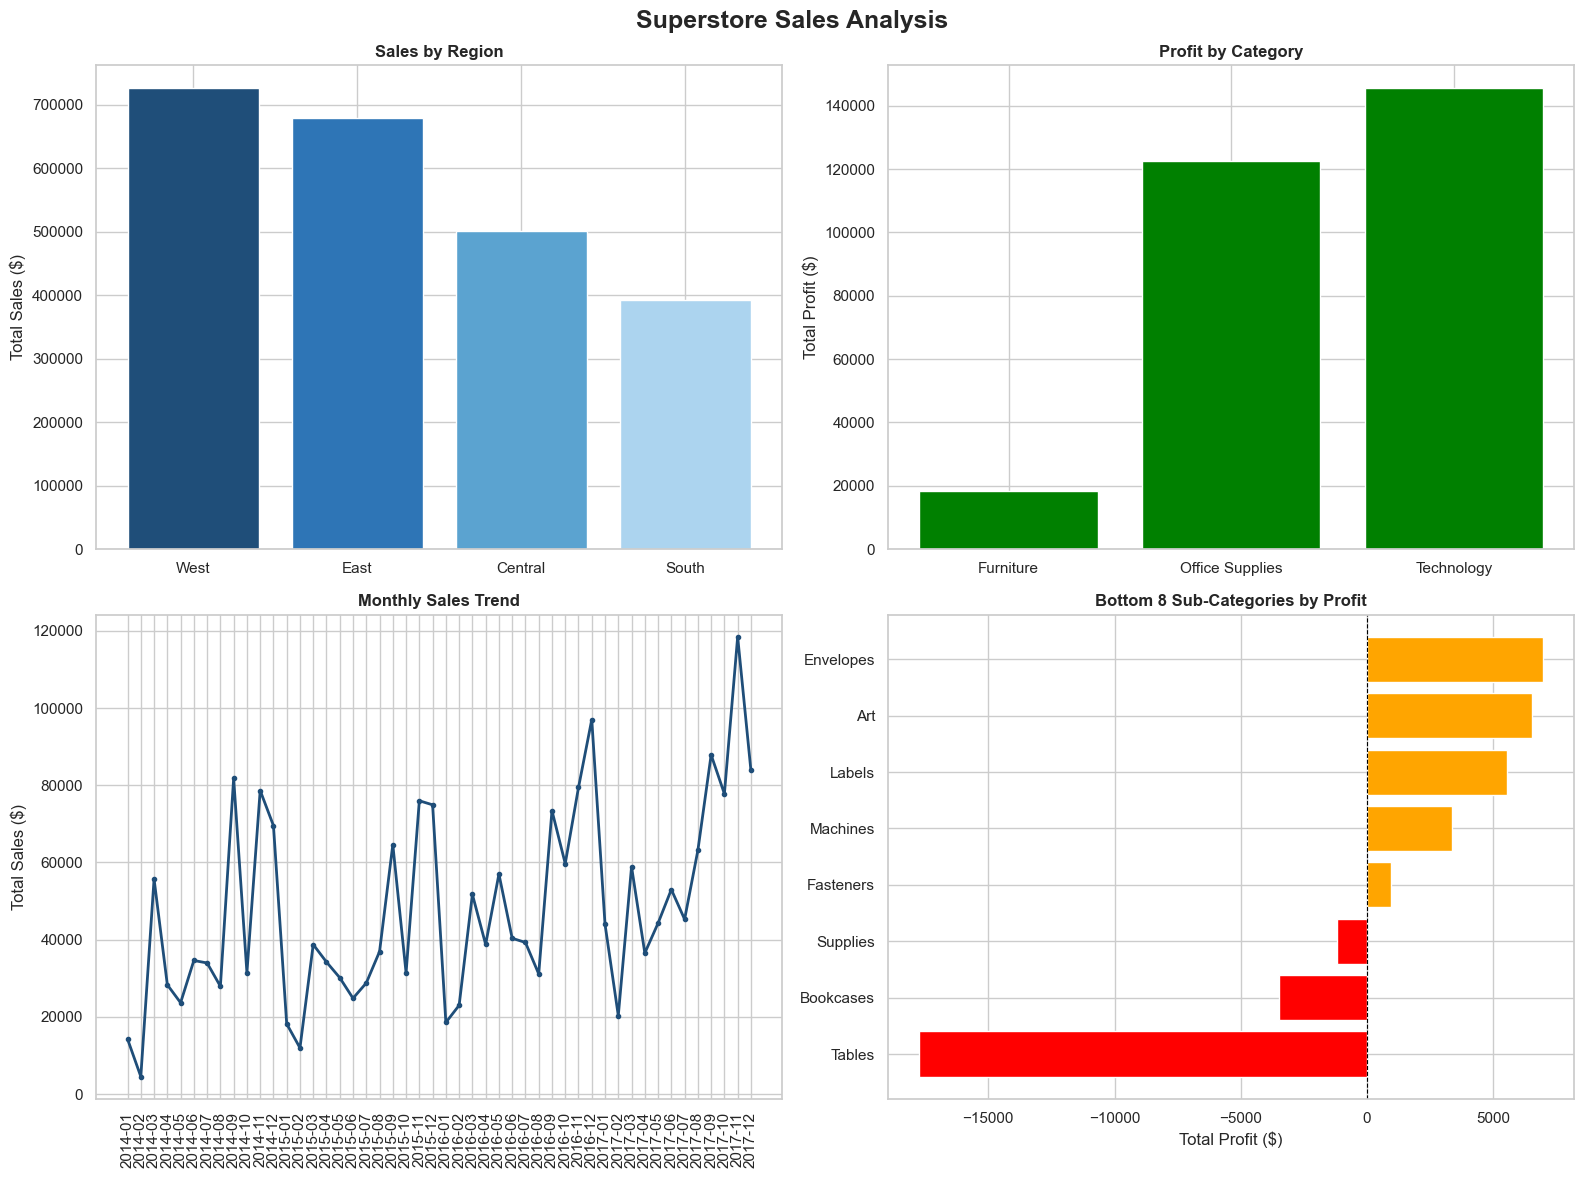

Chart saved to output folder!


In [8]:
# Set the visual style
sns.set_theme(style="whitegrid")
fig , axes = plt.subplots(2,2, figsize=(16,12))
fig.suptitle("Superstore Sales Analysis", fontsize=18, fontweight='bold')

# Chart 1: Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[0,0].bar(region_sales.index, region_sales.values, color=['#1F4E79','#2E75B6','#5BA3D0','#ACD4EF'])
axes[0,0].set_title("Sales by Region", fontweight='bold')
axes[0,0].set_ylabel("Total Sales ($)")

# Chart 2: Profit by Category
category_profit = df.groupby('Category')['Profit'].sum()
colors_cat = ['green' if x > 0 else 'red' for x in category_profit.values]
axes[0,1].bar(category_profit.index, category_profit.values, color=colors_cat)
axes[0,1].set_title("Profit by Category", fontweight='bold')
axes[0,1].set_ylabel("Total Profit ($)")

# Chart 3: Monthly Sales Trend
monthly_sales = df.groupby(['Order Year','Order Month'])['Sales'].sum().reset_index()
monthly_sales['Period'] = monthly_sales['Order Year'].astype(str) + '-' + monthly_sales['Order Month'].astype(str).str.zfill(2)
axes[1,0].plot(monthly_sales['Period'], monthly_sales['Sales'], color='#1F4E79',linewidth=2, marker='o', markersize=3)
axes[1,0].set_title("Monthly Sales Trend", fontweight='bold')
axes[1,0].set_ylabel("Total Sales ($)")
axes[1,0].tick_params(axis='x', rotation=90)

# Chart 4: Loss Making Sub-Categories
loss_subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values().head(8)
colors_loss = ['red' if x < 0 else 'orange' for x in loss_subcat.values]
axes[1,1].barh(loss_subcat.index, loss_subcat.values, color=colors_loss)
axes[1,1].set_title("Bottom 8 Sub-Categories by Profit", fontweight='bold')
axes[1,1].set_xlabel("Total Profit ($)")
axes[1,1].axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('../output/sales_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to output folder!")




In [9]:
# Save the  cleaned and enriched dataset 
df.to_csv('../data/superstore_cleaned.csv', index=False)
print("Cleaned dataset saved !")
print(f"Shape: {df.shape}")
print(f"New Columns added : {['Order Year', 'Order Month', 'Order Month Name', 'Order Quarter', 'Shipping Days']}")

Cleaned dataset saved !
Shape: (9994, 26)
New Columns added : ['Order Year', 'Order Month', 'Order Month Name', 'Order Quarter', 'Shipping Days']
